In [28]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import auc, roc_curve, classification_report
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score, KFold,train_test_split, GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error,mean_squared_error
from xgboost.sklearn import XGBRegressor

import shap

%matplotlib inline

# 1. Load Data

In [4]:
# Upload file from local drive
#from google.colab import files
#upload_file = files.upload()

In [5]:
data = pd.read_csv('srdb-data.csv')

In [6]:
data.head()

,Record_number,Entry_date,Study_number,Author,Duplicate_record,Quality_flag,Contributor,Country,Region,Site_name,...,BA,C_veg_total,C_AG,C_BG,C_CR,C_FR,C_litter,C_soilmineral,C_soildepth,Notes
0,1.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1998,...,0.0,200.0,80.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
1,2.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1995,...,0.5,160.0,90.0,70.0,40.0,30.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
2,3.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1989,...,0.0,520.0,400.0,120.0,70.0,50.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
3,4.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1981,...,4.1,1050.0,700.0,350.0,230.0,120.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...
4,5.0,2008-09-26,2534,Bond-Lamberty,NaN,Q02,BBL,Canada,Manitoba,BOREAS NSA-D1964,...,11.6,2300.0,1500.0,800.0,600.0,200.0,NaN,41800.0,70.0,LAI from Bond-Lamberty (2002); C from Wang (20...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12272 entries, 0 to 12271
Data columns (total 85 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Record_number       12272 non-null  float64
 1   Entry_date          12272 non-null  object 
 2   Study_number        12272 non-null  int64  
 3   Author              12270 non-null  object 
 4   Duplicate_record    104 non-null    object 
 5   Quality_flag        3457 non-null   object 
 6   Contributor         12272 non-null  object 
 7   Country             12261 non-null  object 
 8   Region              9454 non-null   object 
 9   Site_name           10834 non-null  object 
 10  Site_ID             11753 non-null  object 
 11  Study_midyear       12078 non-null  float64
 12  YearsOfData         12074 non-null  float64
 13  Latitude            11883 non-null  float64
 14  Longitude           11881 non-null  float64
 15  Elevation           7053 non-null   float64
 16  Mani

In [ ]:
"""
for column in features:
    if pd.api.types.is_string_dtype(data[column]):
        uniques = sorted(data[column].unique())
        print('{0:20s} {1:5d}\t'.format(column, len(uniques)), uniques[:5])
"""

"\nfor column in features:\n    if pd.api.types.is_string_dtype(data[column]):\n        uniques = sorted(data[column].unique())\n        print('{0:20s} {1:5d}\t'.format(column, len(uniques)), uniques[:5])\n"

In [7]:
missing = pd.DataFrame(data.isna().sum()/len(data))
missing

,0
Record_number,0.000000
Entry_date,0.000000
Study_number,0.000000
Author,0.000163
Duplicate_record,0.991525
...,...
C_FR,0.929922
C_litter,0.952493
C_soilmineral,0.887712
C_soildepth,0.903439


# 2. EDA

#### Study midyear

In [8]:
data['Study_midyear'].head()


,Study_midyear
0,2001.5
1,2001.5
2,2001.5
3,2001.5
4,2001.5


In [9]:
data['Study_year'] = np.floor(data['Study_midyear'])

In [10]:
data['Study_year'].head()

,Study_year
0,2001.0
1,2001.0
2,2001.0
3,2001.0
4,2001.0


#### Quality_flag

In [11]:
col='Quality_flag'
uniques = data[col].unique()
print('{0:20s} {1:5d}\t'.format(col, len(uniques)), uniques)

Quality_flag            32	 ['Q02' 'Q01' nan 'Q10' 'Q03' 'Q2' 'Q1,Q10' 'Q03,Q10,Q16' 'Q11' 'Q16'
 'Q10,Q13' 'Q03,Q12' 'Q01,Q11' 'Q03,Q10' 'Q12' 'Q13' 'Q03,Q13' 'Q01,Q13'
 'Q01,Q03' 'Q04' 'Q03, Q11' 'Q15' 'Q01,Q10' 'Q11,Q12' 'Q01,Q16' 'Q01, Q11'
 'Q11,Q14' 'Q1' 'Q01,Q14' 'Q3' 'Q01, Q03' 'Q0']


In [12]:

"""
Quality_flag
Quality control flags are as follows:
		Q0	default (none)
		Q01	estimated from figure
		Q02	data from another study
		Q03	data estimated--other
		Q04	potentially useful future data
		Q10	potential problem with data
		Q11	suspected problem with data
		Q12	known problem with data
		Q13	duplicate?
		Q14	inconsistency
		Q15	seasonal model, not annual
		Q16	model has a soil water component or dependency


"""

'\nQuality_flag\nQuality control flags are as follows:\n\t\tQ0\tdefault (none)\n\t\tQ01\testimated from figure\n\t\tQ02\tdata from another study\n\t\tQ03\tdata estimated--other\n\t\tQ04\tpotentially useful future data\n\t\tQ10\tpotential problem with data\n\t\tQ11\tsuspected problem with data\n\t\tQ12\tknown problem with data\n\t\tQ13\tduplicate?\n\t\tQ14\tinconsistency\n\t\tQ15\tseasonal model, not annual\n\t\tQ16\tmodel has a soil water component or dependency\n\n\n'

#### Ecosystem_type

In [ ]:
col='Ecosystem_type'
data[[col]].isna().sum()/len(data)

Ecosystem_type    0.007171
dtype: float64

In [13]:
col='Ecosystem_type'
uniques = data[col].unique()
print('{0:20s} {1:5d}\t'.format(col, len(uniques)), uniques)
print(data[col].isna().sum()/len(data))


Ecosystem_type          19	 ['Forest' 'Grassland' 'Agriculture' 'Shrubland' 'Wetland' 'Desert'
 'Savanna' 'Tundra' 'Urban' 'Bare' 'Mixed' nan 'Orchard' 'Salt pan'
 'Forest ' 'Waterlogged depression' 'Peatland' 'Grassland ' 'Cropland']
0.007170795306388526


In [14]:
data[[col]].value_counts()

,count
Ecosystem_type,
Forest,6228
Grassland,2297
Agriculture,2234
Shrubland,487
Wetland,479
Desert,194
Tundra,84
Savanna,76
Bare,23


In [ ]:
data[col].dtype

dtype('O')

In [15]:
ecosystem_types = data[col].unique()
for idx in range(len(ecosystem_types)):
    ecosystem_types[idx] = str(ecosystem_types[idx] )

ecosystem_types.sort()
print(ecosystem_types)

['Agriculture' 'Bare' 'Cropland' 'Desert' 'Forest' 'Forest ' 'Grassland'
 'Grassland ' 'Mixed' 'Orchard' 'Peatland' 'Salt pan' 'Savanna'
 'Shrubland' 'Tundra' 'Urban' 'Waterlogged depression' 'Wetland' 'nan']


In [16]:
#### Remove space in ecosystem strings
data[[col]] = data[[col]].applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [17]:
data[col].value_counts()

,count
Ecosystem_type,
Forest,6236
Grassland,2305
Agriculture,2234
Shrubland,487
Wetland,479
Desert,194
Tundra,84
Savanna,76
Bare,23


#### Biome

In [18]:
col='Biome'
data[[col]].isna().sum()/len(data)

,0
Biome,0.020698


In [19]:
col='Biome'
data[['Record_number', col]].groupby(col).count()

,Record_number
Biome,
Alpine,164
Arctic,135
Boreal,1377
Continental,5
Continental monsoon,8
Grassland,4
Mediterranean,634
Semi-Arid,2
Semi-arid,4


In [20]:
col='Biome'
biome_ecosystem = data[['Record_number', col, 'Ecosystem_type']].groupby([col, 'Ecosystem_type']).count().reset_index()

In [21]:
biome_ecosystem

,Biome,Ecosystem_type,Record_number
0,Alpine,Forest,17
1,Alpine,Grassland,129
2,Alpine,Tundra,3
3,Alpine,Wetland,15
4,Arctic,Desert,8
...,...,...,...
72,Tropical,Urban,5
73,Tropical,Wetland,31
74,Tundra,Forest,6
75,Tundra,Grassland,12


#### Rs_annual

<Axes: xlabel='Rs_annual', ylabel='Density'>

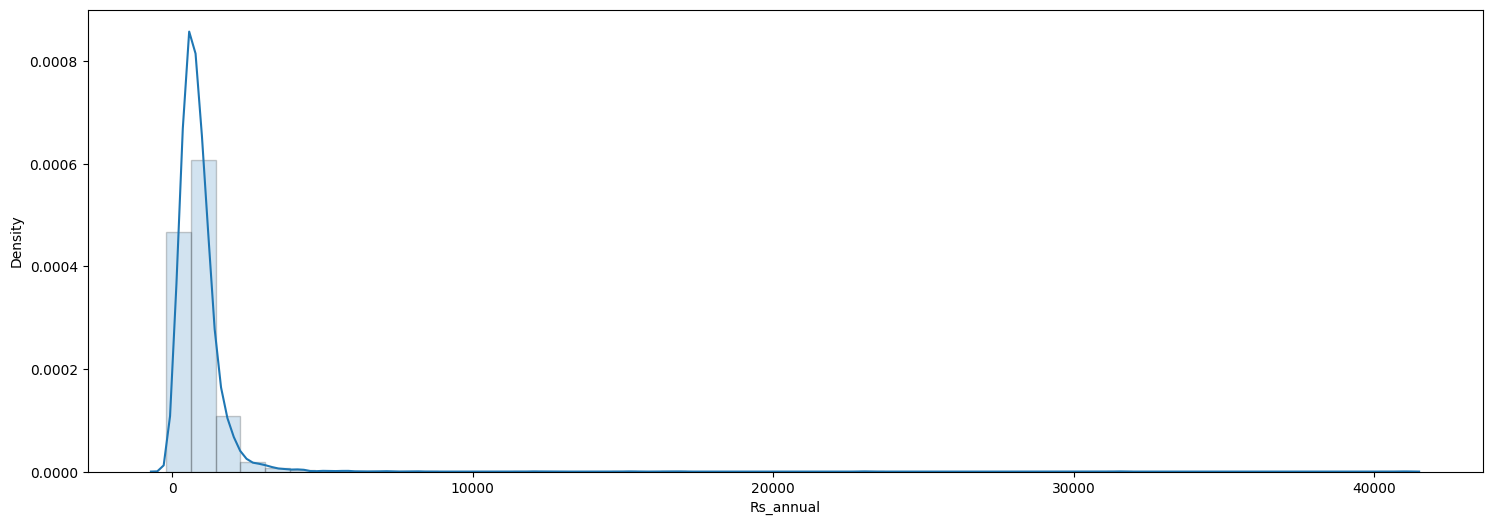

In [22]:
col = 'Rs_annual'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
hist_kws={'histtype': 'bar', 'edgecolor':'black', 'alpha': 0.2}
sns.distplot(data[col], label='Rs_annual',
             hist_kws=hist_kws)

Text(0.5, 1.0, 'Rs_annual vs MAT')

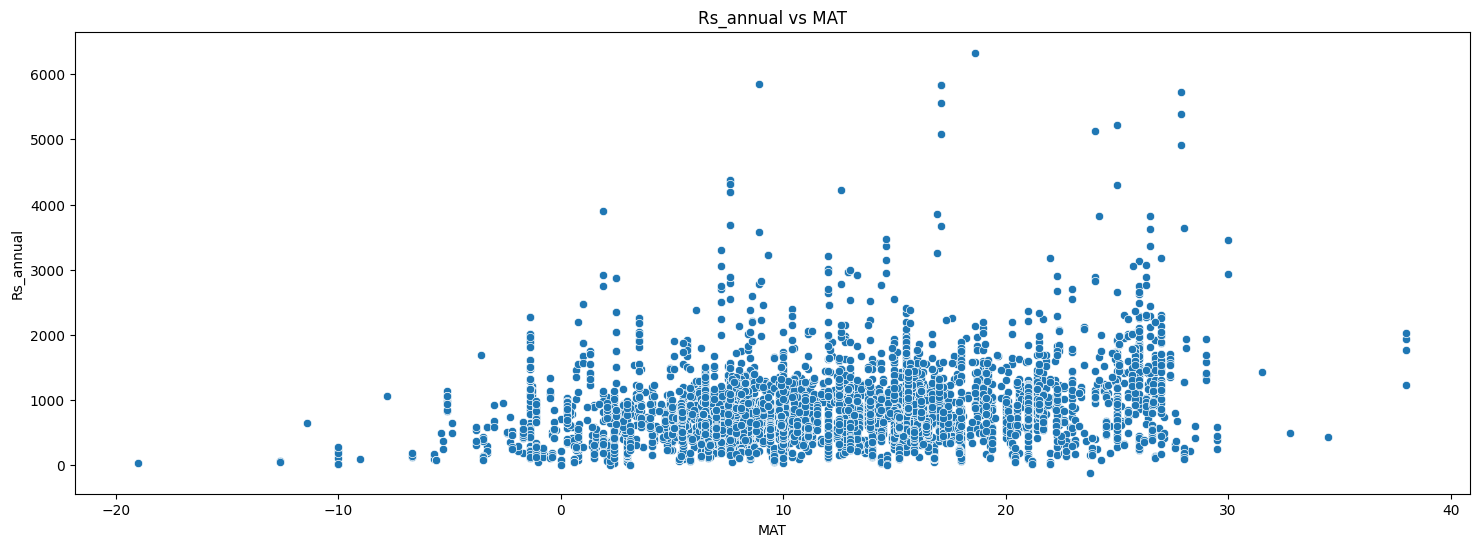

In [23]:
y_col = 'Rs_annual'
x_col = 'MAT'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
sns.scatterplot(x=x_col, y=y_col, data=data, ax=ax)
ax.set_title('Rs_annual vs MAT')


Text(0.5, 1.0, 'Rs_annual vs MAP')

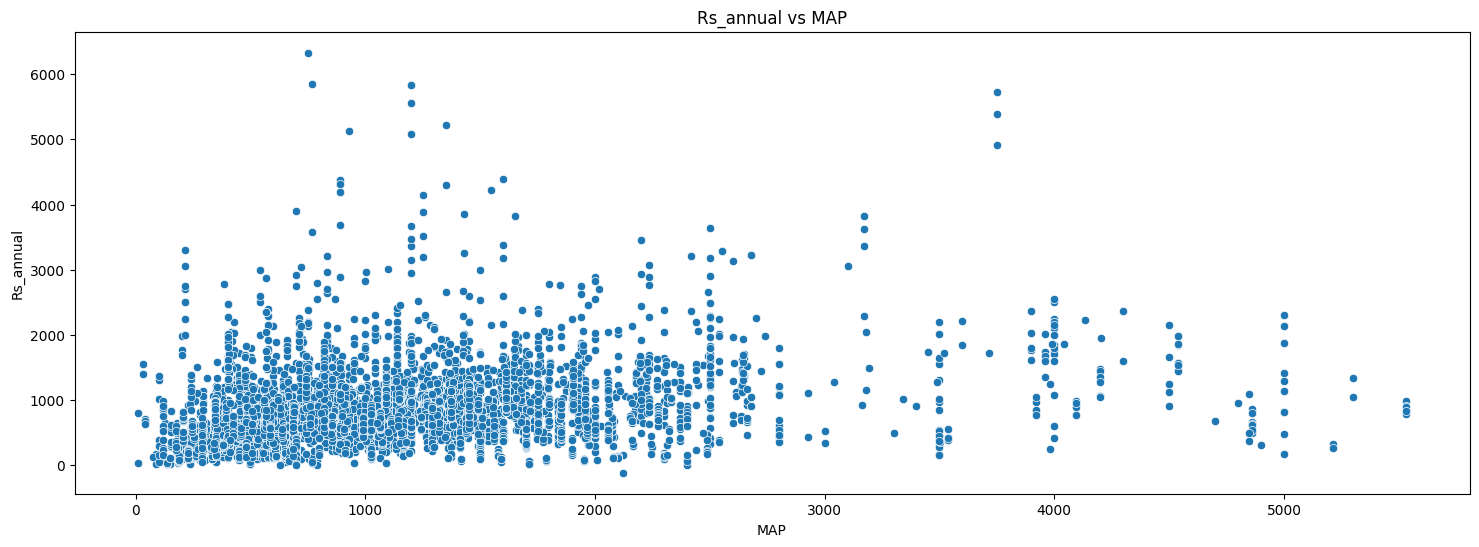

In [24]:
y_col = 'Rs_annual'
x_col = 'MAP'

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))
sns.scatterplot(x=x_col, y=y_col, data=data, ax=ax)
ax.set_title('Rs_annual vs MAP')


## 2.1 Data exclusion


In [ ]:
accept_flag =['Q02', 'Q01', 'Q03', 'Q2',
       'Q01,Q03',  'Q1',
    'Q3', 'Q01, Q03', 'Q0']

In [ ]:
clean_data = data.loc[((data['Quality_flag'].isna())|(data['Quality_flag'].isin(accept_flag))) & (~data['Rs_annual'].isna())]

In [ ]:
print('Original # row:', len(data), 'Clean # rows:', len(clean_data))

Original # row: 12272 Clean # rows: 6393


In [ ]:
clean_data[['Record_number','Ecosystem_type']].groupby('Ecosystem_type').count()

,Record_number
Ecosystem_type,
Agriculture,848
Bare,13
Cropland,3
Desert,86
Forest,3818
Grassland,943
Mixed,6
Orchard,8
Peatland,2


## 2.2 Feature selection

In [ ]:
# Explanatory variables:
"""
Spatial–Temporal Data
13,YearsOfData,Years of data; always ?1
14,Latitude,"Latitude, decimal (positive=north, negative=south)"
15,Longitude,"Longitude, decimal (positive=east, negative=west)"
16,Elevation,"Elevation, m"
22,Biome,"Biome (boreal, temperate, etc). Subjective"

Climate data
34,MAT,"Reported mean annual temperature, deg C"
35,MAP,"Reported mean annual precipitation, mm"

Vegetation data
25,Leaf_habit,"Dominant leaf habit (deciduous, evergreen)"
26,Stage,"Developmental stage (aggrading, mature). Subjective"
75,LAI,"Leaf area index at site, m2 m-2. Hemispheric (one-sided) if possible"

Soil data
27,Soil_type,Soil description (classification and texture)
28,Soil_drainage,"Soil drainage (dry, wet). Subjective. 'Dry' means well-drained uplands; 'wet' peatlands, swamps, etc."
29,Soil_BD,"Soil bulk density, g cm-3"
30,Soil_CN, Soil C:N ratio
31,Soil_sand, Sand ratio value (generally sand+silt+clay = 100 but not always)
32,Soil_silt, Silt ratio value (generally sand+silt+clay = 100 but not always)
33,Soil_clay, Clay ratio value (generally sand+silt+clay = 100 but not always)

Land use data
23,Ecosystem_type,"Ecosystem type (grassland, forest, etc). Subjective"
24,Ecosystem_state,"Ecosystem state (managed, unmanaged, natural). Subjective. 'Unmanaged' means human management or disturbance in the past, but not currently."

"""

'\nSpatial–Temporal Data\n13,YearsOfData,Years of data; always ?1\n14,Latitude,"Latitude, decimal (positive=north, negative=south)"\n15,Longitude,"Longitude, decimal (positive=east, negative=west)"\n16,Elevation,"Elevation, m"\n22,Biome,"Biome (boreal, temperate, etc). Subjective"\n\nClimate data\n34,MAT,"Reported mean annual temperature, deg C"\n35,MAP,"Reported mean annual precipitation, mm"\n\nVegetation data\n25,Leaf_habit,"Dominant leaf habit (deciduous, evergreen)"\n26,Stage,"Developmental stage (aggrading, mature). Subjective"\n75,LAI,"Leaf area index at site, m2 m-2. Hemispheric (one-sided) if possible"\n\nSoil data\n27,Soil_type,Soil description (classification and texture)\n28,Soil_drainage,"Soil drainage (dry, wet). Subjective. \'Dry\' means well-drained uplands; \'wet\' peatlands, swamps, etc."\n29,Soil_BD,"Soil bulk density, g cm-3"\n30,Soil_CN, Soil C:N ratio\n31,Soil_sand, Sand ratio value (generally sand+silt+clay = 100 but not always)\n32,Soil_silt, Silt ratio value (g

In [ ]:
spatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']
climate_features = ['MAT', 'MAP']
vegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]
landuse_features = ['Ecosystem_type', 'Ecosystem_state']
soil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']

### Climate features

In [ ]:
data[climate_features].head()

,MAT,MAP
0,0.8,450.0
1,0.8,450.0
2,0.8,450.0
3,0.8,450.0
4,0.8,450.0


In [ ]:
print('Missing values:')
data[climate_features].isna().sum()/len(data)

Missing values:


,0
MAT,0.255460
MAP,0.195893


### Spatial_temporal_features

In [ ]:
data[spatial_temporal_features].head()

,YearsOfData,Latitude,Longitude,Elevation,Biome
0,1.5,56.63,-99.94,NaN,Boreal
1,1.5,56.46,-99.97,NaN,Boreal
2,1.5,55.91,-98.98,NaN,Boreal
3,1.5,55.86,-98.48,NaN,Boreal
4,1.5,55.92,-98.39,NaN,Boreal


In [ ]:
print('Missing values:')
data[spatial_temporal_features].isna().sum()/len(data)

Missing values:


,0
YearsOfData,0.016134
Latitude,0.031698
Longitude,0.031861
Elevation,0.425277
Biome,0.020698


#### A lot of missing values in "Elevation"

### Vegetation features

In [ ]:
data[vegetation_features].head()

,Leaf_habit,Stage,LAI
0,Evergreen,Aggrading,0.0
1,Deciduous,Aggrading,0.1
2,Deciduous,Aggrading,0.0
3,Mixed,Aggrading,0.9
4,Evergreen,Aggrading,1.8


In [ ]:
data[vegetation_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12272 entries, 0 to 12271
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Leaf_habit  11857 non-null  object 
 1   Stage       11946 non-null  object 
 2   LAI         965 non-null    float64
dtypes: float64(1), object(2)
memory usage: 287.8+ KB


In [ ]:
print('Missing values:')
data[vegetation_features].isna().sum()/len(data)

Missing values:


,0
Leaf_habit,0.033817
Stage,0.026565
LAI,0.921366


#### A lot of missing values in "LAI"

### Land use features

In [ ]:
data[landuse_features].head()

,Ecosystem_type,Ecosystem_state
0,Forest,Natural
1,Forest,Natural
2,Forest,Natural
3,Forest,Natural
4,Forest,Natural


In [ ]:
print('Missing values:')
data[landuse_features].isna().sum()/len(data)

Missing values:


,0
Ecosystem_type,0.007171
Ecosystem_state,0.008882


### Soil features

In [ ]:
data[soil_features].head()

,Soil_type,Soil_drainage,Soil_BD,Soil_CN,Soil_sand,Soil_silt,Soil_clay
0,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN
1,Gray luvisol (Boralf),Dry,NaN,NaN,NaN,NaN,NaN
2,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN
3,Gray luvisol (Boralf),Dry,NaN,NaN,NaN,NaN,NaN
4,Gray luvisol (Boralf),Medium,NaN,NaN,NaN,NaN,NaN


In [ ]:
data[soil_features].describe()

,Soil_BD,Soil_CN,Soil_sand,Soil_silt,Soil_clay
count,3398.000000,2864.000000,2059.000000,2050.000000,2169.000000
mean,1.117124,16.541947,45.991585,32.964813,21.181749
std,0.435891,10.390204,23.193085,17.674867,14.062656
min,0.050000,0.230000,0.600000,0.018100,0.000000
25%,0.950000,10.330000,29.600000,20.000000,11.000000
50%,1.200000,13.320000,45.000000,32.500000,20.000000
75%,1.330000,20.000000,62.750000,42.800000,28.000000
max,9.300000,113.200000,99.300000,85.000000,76.000000


In [ ]:
print('Missing values:')
data[soil_features].isna().sum()/len(data)

Missing values:


,0
Soil_type,0.205590
Soil_drainage,0.034958
Soil_BD,0.723110
Soil_CN,0.766623
Soil_sand,0.832220
Soil_silt,0.832953
Soil_clay,0.823256


# 3. Construct model


## 3.1 Feature encoding

In [25]:
"""
spatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']
climate_features = ['MAT', 'MAP']
vegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]
landuse_features = ['Ecosystem_type', 'Ecosystem_state']
soil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']
"""

"\nspatial_temporal_features = ['YearsOfData', 'Latitude', 'Longitude', 'Elevation', 'Biome']\nclimate_features = ['MAT', 'MAP']\nvegetation_features = ['Leaf_habit', 'Stage', 'LAI' ]\nlanduse_features = ['Ecosystem_type', 'Ecosystem_state']\nsoil_features = ['Soil_type', 'Soil_drainage', 'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay']\n"

In [ ]:
# label encoding
columns = ['Leaf_habit', 'Stage', 'Elevation', 'Biome', 'Ecosystem_type', 'Ecosystem_state', 'Soil_type', 'Soil_drainage']

for col in columns:
    clean_data[col] = data[col].astype(str)

    # one hot encoding
    enc = LabelEncoder()
    # fit transform training dataset
    enc_data = pd.DataFrame(enc.fit_transform(clean_data[[col]]))
    col_name = col+'_label'
    clean_data[col_name] = enc_data

In [ ]:
features =['Study_year', 'YearsOfData', 'Latitude', 'Longitude', 'Elevation_label', 'Biome_label',
    'MAT', 'MAP',
    'Leaf_habit_label', 'Stage_label',
    'Ecosystem_type_label', 'Ecosystem_state_label',
    'Soil_type_label', 'Soil_drainage_label',
    'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay',
    'LAI']

target = 'Rs_annual'

In [ ]:
# Includ all features
features =['Study_year', 'YearsOfData', 'Latitude', 'Longitude', 'Elevation_label', 'Biome_label',
    'MAT', 'MAP',
    'Leaf_habit_label', 'Stage_label',
    'Ecosystem_type_label', 'Ecosystem_state_label',
    'Soil_type_label', 'Soil_drainage_label']

target = 'Rs_annual'

In [ ]:
#clean_data[features] = clean_data[features].fillna(clean_data[features].median())

In [ ]:
clean_data[features].isna().sum()

,0
Study_year,56
YearsOfData,45
Latitude,156
Longitude,158
Elevation_label,2726
Biome_label,2726
MAT,1428
MAP,1087
Leaf_habit_label,2726
Stage_label,2726


In [ ]:
clean_data[target].isna().sum()

0

## 3.2 Train-test split

In [ ]:
#Train and test sets split: train - 70%, test -30%
train, test = train_test_split(clean_data[features+[target]], test_size=0.2, random_state=2)

In [ ]:
train.sample(2)

,Study_year,YearsOfData,Latitude,Longitude,Elevation_label,Biome_label,MAT,MAP,Leaf_habit_label,Stage_label,Ecosystem_type_label,Ecosystem_state_label,Soil_type_label,Soil_drainage_label,Rs_annual
5815,2013.0,1.5,34.78,135.83,109.0,8.0,15.5,1449.0,3.0,0.0,4.0,0.0,248.0,0.0,794.0
5848,2010.0,2.0,-43.03,171.75,252.0,9.0,NaN,NaN,0.0,0.0,0.0,0.0,155.0,0.0,363.0


In [ ]:
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [ ]:
y_train.isna().sum()

0

## 3.2 Model Training

### Hyper-parameter tuning

In [ ]:
xgb_model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468,
                             learning_rate=0.05, max_depth=3,
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)

In [ ]:
# grid search xgboost hyperparameter
xgb_params = {
    "n_estimators": [500, 400],
    "max_depth": [5, 7, 10],
    "learning_rate": [0.01, 0.05, .1],
    "subsample": [0.6, 0.9],
}
kfold = KFold(n_splits=3, shuffle=True, random_state=1)
xgb_grid = GridSearchCV(XGBRegressor(), xgb_params, verbose=5, scoring='neg_mean_squared_error', n_jobs=-1, cv=kfold)
xgb_grid_result = xgb_grid.fit(X_train.values, y_train.values.ravel())

Fitting 3 folds for each of 36 candidates, totalling 108 fits


In [ ]:
# summary of results
print ("Best: %f using %s" % (xgb_grid_result.best_score_, xgb_grid_result.best_params_))
means = xgb_grid_result.cv_results_['mean_test_score']
stds = xgb_grid_result.cv_results_['std_test_score']
params = xgb_grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print ("%f (%f) with: %r" % (mean, stdev, param))

Best: -605888.815530 using {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.9}
-682674.006683 (407079.566421) with: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.6}
-680608.138001 (426544.539213) with: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.9}
-679296.775769 (417338.920571) with: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.6}
-687598.851797 (437799.575149) with: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.9}
-642205.900879 (395355.758644) with: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.6}
-635853.337842 (404128.794331) with: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.9}
-638429.487134 (405772.764948) with: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.6}
-642711.327937 (413594.877812) with: {'learning_rate': 0.01, 'max_depth': 7, 'n_e

In [ ]:
xgb_model = xgb_grid.best_estimator_
xgb_model

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.01, max_delta_step=0, max_depth=10,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=500, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.9,
             tree_method='exact', validate_parameters=1, verbosity=None)

### Run model without hyper-parameter tuning

In [ ]:
"""
xgb_model =XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.05, max_delta_step=0, max_depth=7,
             min_child_weight=1, monotone_constraints='()',
             n_estimators=500, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.9,
             tree_method='exact', validate_parameters=1, verbosity=None)
"""

In [ ]:
xgb_model =XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.05, max_delta_step=0, max_depth=7,
             min_child_weight=1, monotone_constraints='()',
             n_estimators=500, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.9,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [ ]:
xgb_model_results = xgb_model.fit(X_train.values, y_train.values.ravel())

In [ ]:
train_predict = xgb_model.predict(X_train.values)

In [ ]:
train_predict

array([1242.6987 ,  832.82916, 1311.0067 , ...,  363.76178, 1130.4061 ,
        540.2198 ], dtype=float32)

In [ ]:
print('Train MAE : %f' % (mean_absolute_error(y_train, train_predict)))
print('Train RMSE : %f' % (np.sqrt(mean_squared_error(y_train, train_predict))))
print('Train R2 : %f' % (r2_score(y_train, train_predict)))
print('\n')

Train MAE : 138.637545
Train RMSE : 540.108114
Train R2 : 0.601005




In [ ]:
test_predict = xgb_model.predict(X_test.values)
print('Test MAE : %f' % (mean_absolute_error(y_test, test_predict)))
print('Test RMSE : %f' % (np.sqrt(mean_squared_error(y_test, test_predict))))
print('Test R2 : %f' % (r2_score(y_test, test_predict)))

Test MAE : 226.279831
Test RMSE : 704.878783
Test R2 : 0.615502


# 4 Feature importance and SHAP

In [27]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)
shap_values.shape

NameError: name 'xgb_model' is not defined

## Global feature importance

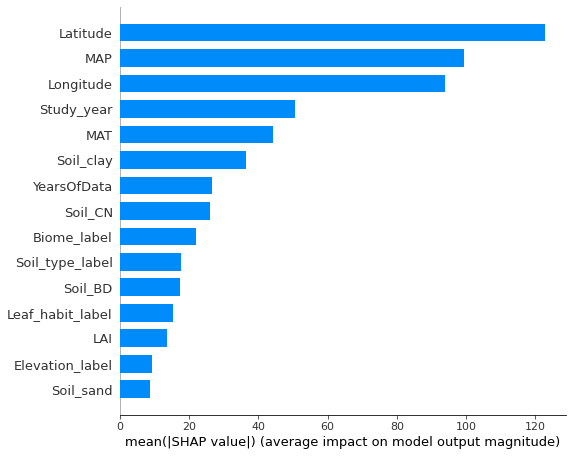

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=15)

## Importance Density, Dispersion, and Directionality

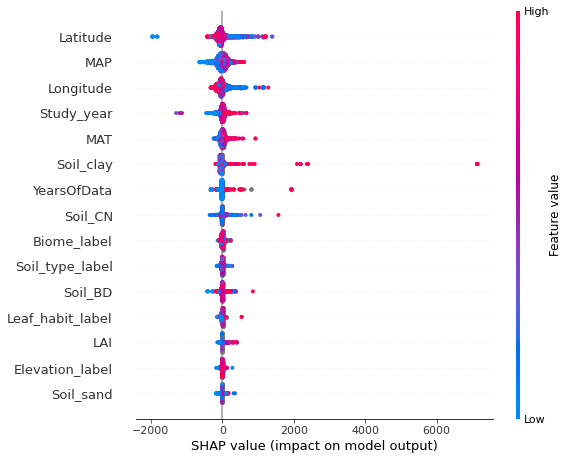

In [ ]:
shap.summary_plot(shap_values, X_train, max_display=15)

## Partial Dependence and Interaction Effects

#### MAP

In [ ]:
print(data['MAP'].max())

5532.0


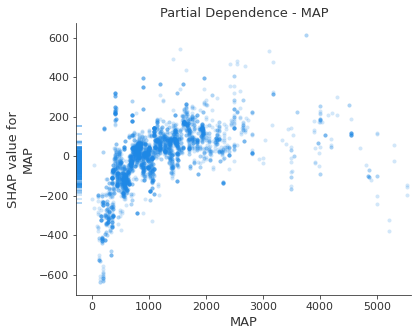

In [ ]:
shap.dependence_plot('MAP', shap_values, X_train, xmax=5600, interaction_index=None,
                     title='Partial Dependence - MAP', alpha=0.2)

#### MAT

In [ ]:
print(data['MAT'].max())

38.0


In [26]:
shap.dependence_plot('MAT', shap_values, X_train, xmax=39, interaction_index=None,
                     title='Partial Dependence - MAT', alpha=0.2)

NameError: name 'shap_values' is not defined

#### Interation between MAP and MAT

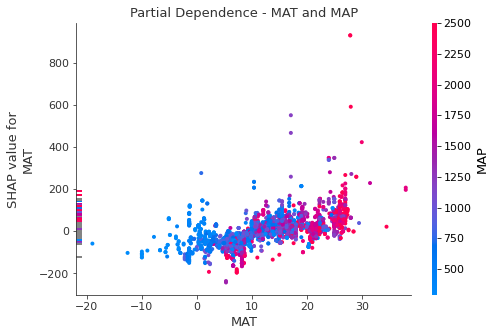

In [ ]:
shap.dependence_plot('MAT', shap_values, X_train, xmax=39, interaction_index='MAP',
                     title='Partial Dependence - MAT and MAP')

## Explanation for individual predictions

In [ ]:
predicted_y = xgb_model.predict(X_test[:20].values)
sv_test = explainer.shap_values(X_test[:20].values)
print(predicted_y.shape, sv_test.shape)

(20,) (20, 20)


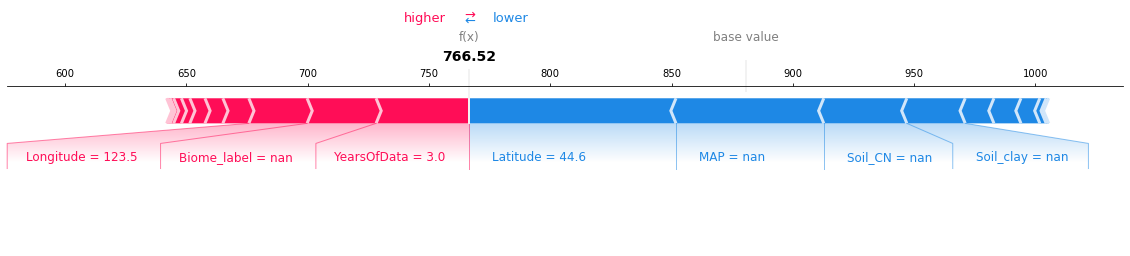

In [ ]:
shap.force_plot(explainer.expected_value, sv_test[8,:], X_test.iloc[8,:], matplotlib=True)

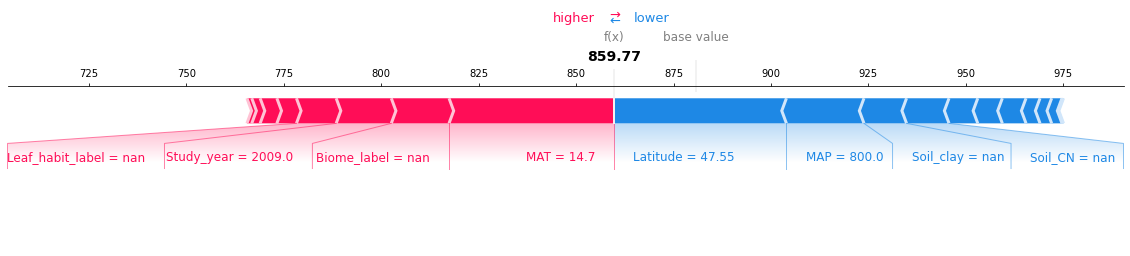

In [ ]:
shap.force_plot(explainer.expected_value, sv_test[0,:], X_test.iloc[0,:], matplotlib=True)

# 5 Neural Network

In [ ]:
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 units, ReLU activation
  tf.keras.layers.Dense(64, activation='relu'), # Hidden layer with 64 units, ReLU activation
  tf.keras.layers.Dense(1, activation='sigmoid') # Output layer with sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', # Adam optimizer for efficient training
              loss='binary_crossentropy', # Binary cross-entropy loss for binary classification
              metrics=['accuracy']) # Accuracy metric to evaluate performance

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32) # Train for 10 epochs with a batch size of 32


# 5. Clustering

In [ ]:
numerical_features =['Study_year', 'YearsOfData', 'Latitude', 'Longitude', 'Elevation_label', 'Biome_label',
    'MAT', 'MAP',
    'Leaf_habit_label', 'Stage_label',
    'Ecosystem_type_label', 'Ecosystem_state_label',
    'Soil_type_label', 'Soil_drainage_label',
    'Soil_BD', 'Soil_CN', 'Soil_sand', 'Soil_silt', 'Soil_clay',
    'LAI', 'Rs_annual']

In [ ]:
for ft in numerical_features:
    print(ft, X_train[ft].dtype)

Study_year float64
YearsOfData float64
Latitude float64
Longitude float64
Elevation_label float64
Biome_label float64
MAT float64
MAP float64
Leaf_habit_label float64
Stage_label float64
Ecosystem_type_label float64
Ecosystem_state_label float64
Soil_type_label float64
Soil_drainage_label float64
Soil_BD float64
Soil_CN float64
Soil_sand float64
Soil_silt float64
Soil_clay float64
LAI float64
Rs_annual float64


In [ ]:
X_train.isna().sum()/len(X_train)

Study_year               0.008604
YearsOfData              0.006648
Latitude                 0.024834
Longitude                0.025029
Elevation_label          0.427063
Biome_label              0.427063
MAT                      0.223113
MAP                      0.169535
Leaf_habit_label         0.427063
Stage_label              0.427063
Ecosystem_type_label     0.427063
Ecosystem_state_label    0.427063
Soil_type_label          0.427063
Soil_drainage_label      0.427063
Soil_BD                  0.733281
Soil_CN                  0.748925
Soil_sand                0.836723
Soil_silt                0.836723
Soil_clay                0.823621
LAI                      0.898905
Rs_annual                0.000000
dtype: float64

In [ ]:
cols = ['Latitude', 'Longitude', 'Biome_label','Rs_annual']

In [ ]:
X_train = train[cols]

In [ ]:
medians = X_train.median()
X_train_seg = X_train.fillna(medians)

In [ ]:
for c in cols:
    print(c, X_train_seg[c].dtype)

Latitude float64
Longitude float64
Biome_label float64
Rs_annual float64


In [ ]:
from sklearn import preprocessing

X_train_norm = preprocessing.normalize(X_train_seg)

In [ ]:
X_train_norm.dtype

dtype('float64')

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, random_state = 0)
kmeans.fit(X_train_norm)

KMeans(n_clusters=5, random_state=0)

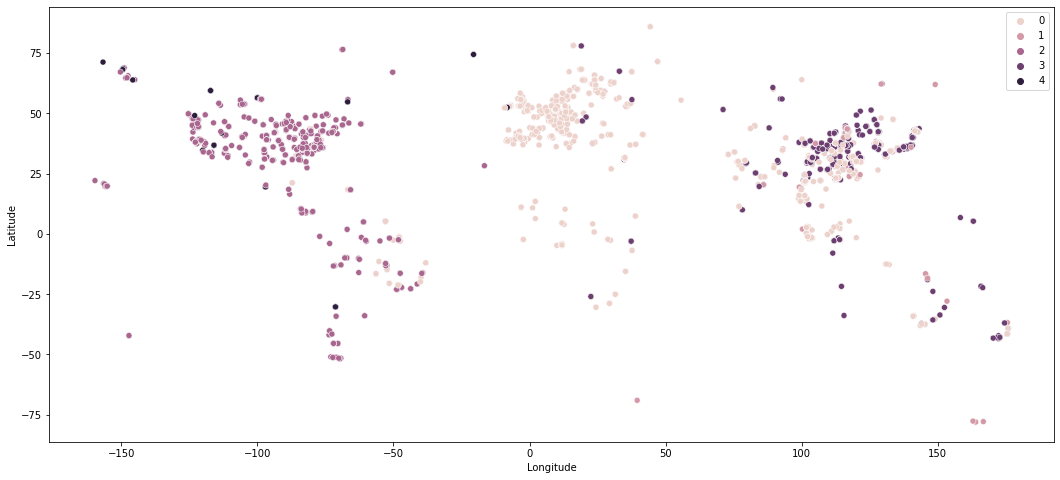

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.scatterplot(data = X_train_seg, x = 'Longitude', y = 'Latitude', hue = kmeans.labels_, ax=ax)
plt.show()

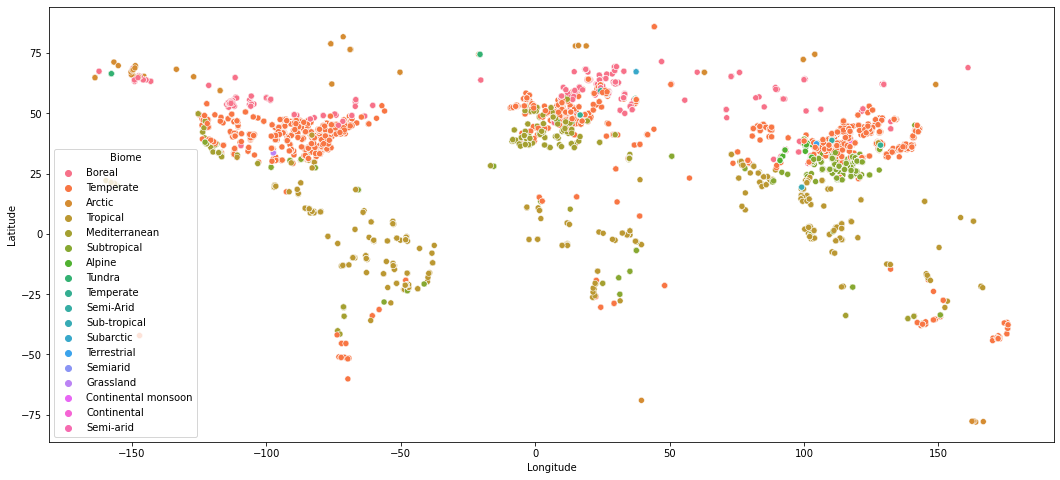

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.scatterplot(data = data, x = 'Longitude', y = 'Latitude', hue = 'Biome', ax=ax)
plt.show()

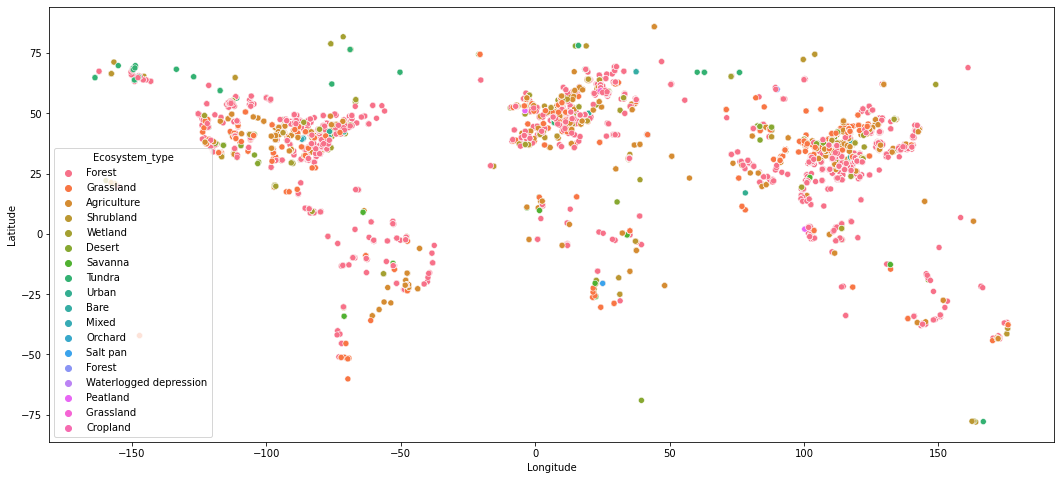

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.scatterplot(data = data, x = 'Longitude', y = 'Latitude', hue = 'Ecosystem_type', ax=ax)
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the world borders shapefile from GeoPandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Select only the continents
continents = world[world['continent'] != 'antarctica']  # Exclude Antarctica if needed

# Create the plot
fig, ax = plt.subplots()

# Plot the continents' contours
continents.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# Set map projection and other adjustments (optional)
ax.set_aspect('equal')
plt.title("Continents Contour Map")
plt.show()

<ipython-input-6-316fd445eb91>:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


AttributeError: module 'fiona' has no attribute 'path'

In [ ]:
pip install geopandas

  Attempting uninstall: click
    Found existing installation: click 7.1.2
    Uninstalling click-7.1.2:
      Successfully uninstalled click-7.1.2
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from mpl_toolkits.basemap import Basemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.nxutils as nx

def points_in_polys(points, polys):
    result = []
    for poly in polys:
        mask = nx.points_inside_poly(points, poly)
        result.extend(points[mask])
        points = points[~mask]
    return np.array(result)

points = np.random.randint(0, 90, size=(100000, 2))
m = Basemap(projection='moll',lon_0=0,resolution='c')
m.drawcoastlines()
m.fillcontinents(color='coral',lake_color='aqua')
x, y = m(points[:,0], points[:,1])
loc = np.c_[x, y]
polys = [p.boundary for p in m.landpolygons]
land_loc = points_in_polys(loc, polys)
m.plot(land_loc[:, 0], land_loc[:, 1],'ro')
plt.show()

ModuleNotFoundError: No module named 'mpl_toolkits.basemap'